# Part 3: Data Cleaning & Feature Engineering

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

## Data Cleaning

In [2]:
# Step 1: Load the dataset
data = pd.read_csv("./data/vienna_listings_starting.csv")

data.head()

,name,description,neighborhood_overview,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price
0,"Near Palace Schönbrunn, Apt. 1",Welcome to my Apt. 1!<br /><br />This is a 2be...,The neighbourhood offers plenty of restaurants...,Rudolfsheim-Fnfhaus,48.18434,16.32701,Entire rental unit,Entire home/apt,6,1.0,1 bath,2.0,3.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",$140.00
1,little studio- next to citycenter- wifi- nice ...,small studio in new renovated old house and ve...,The neighbourhood has a lot of very nice littl...,Leopoldstadt,48.21778,16.37847,Entire rental unit,Entire home/apt,2,1.0,1 bath,0.0,2.0,"[""Smoke alarm"", ""Stove"", ""Coffee maker"", ""Drye...",$71.00
2,Near Palace Schönbrunn - Apt. 4,Studio apartment for 4 persons:<br />- Bunk be...,The neighbourhood offers plenty of restaurants...,Rudolfsheim-Fnfhaus,48.18467,16.32795,Entire rental unit,Entire home/apt,4,1.0,1 bath,0.0,4.0,"[""Smoke alarm"", ""Coffee"", ""Pack \u2019n play/T...",$66.00
3,"Near Palace Schönbrunn, Apt. 5",Studio apartment for 4 persons:<br />- Bunk be...,The neighbourhood offers plenty of restaurants...,Rudolfsheim-Fnfhaus,48.18445,16.32722,Entire rental unit,Entire home/apt,4,1.0,1 bath,0.0,3.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",$96.00
4,"Holiday Apartment ""Modern Vienna""",Modern ambiance in a turn of the century house...,"Bakerys, Viennese wine taverns (“Heurige“) wit...",Ottakring,48.21543,16.30939,Entire rental unit,Entire home/apt,4,NaN,1 bath,2.0,NaN,"[""Stove"", ""Coffee maker"", ""Long term stays all...",NaN


In [3]:
# Step 2: Removing Duplicates
print(f"Number of rows before removing duplicates: {len(data)}")
data = data.drop_duplicates()
print(f"Number of rows after removing duplicates: {len(data)}")
data = data.drop_duplicates(subset=["name"], keep="first")
print(f"Number of rows after removing duplicates based on 'name': {len(data)}")

Number of rows before removing duplicates: 14123
Number of rows after removing duplicates: 14117
Number of rows after removing duplicates based on 'name': 13627


In [4]:
# Step 3: Remove irrelevant columns
columns_to_drop = [
    "name",
    "description",
    "neighborhood_overview",
    "property_type",
    "latitude",
    "longitude",
]
data = data.drop(columns=columns_to_drop)
print(f"Columns after dropping irrelevant ones: {data.columns.tolist()}")

Columns after dropping irrelevant ones: ['neighbourhood_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price']


In our example the `price` column will be the **target variable**.

In [5]:
# Step 3: Cleaning Strings - Clean the 'price' column by removing the '$' sign and converting it to a numeric type
data["price"] = data["price"].str.replace("$", "").str.replace(",", "").astype(float)
data.head()

,neighbourhood_cleansed,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price
0,Rudolfsheim-Fnfhaus,Entire home/apt,6,1.0,1 bath,2.0,3.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",140.0
1,Leopoldstadt,Entire home/apt,2,1.0,1 bath,0.0,2.0,"[""Smoke alarm"", ""Stove"", ""Coffee maker"", ""Drye...",71.0
2,Rudolfsheim-Fnfhaus,Entire home/apt,4,1.0,1 bath,0.0,4.0,"[""Smoke alarm"", ""Coffee"", ""Pack \u2019n play/T...",66.0
3,Rudolfsheim-Fnfhaus,Entire home/apt,4,1.0,1 bath,0.0,3.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",96.0
4,Ottakring,Entire home/apt,4,NaN,1 bath,2.0,NaN,"[""Stove"", ""Coffee maker"", ""Long term stays all...",NaN


In [6]:
# Step 4: Convert 'bathrooms_text' to numeric values and rename the column to 'total_bathrooms'
import re


def parse_bathrooms(text):
    if pd.isna(text):
        return 0
    text = str(text).lower().strip()
    if text in ["half-bath", "shared half-bath", "private half-bath"]:
        return 0.5
    match = re.match(r"(\d+\.?\d*)", text)
    if match:
        return float(match.group(1))
    return 0


data["bathrooms_text"] = data["bathrooms_text"].apply(parse_bathrooms)

# Rename the column to 'total_bathrooms'
data = data.rename(columns={"bathrooms_text": "total_bathrooms"})
data.head()

,neighbourhood_cleansed,room_type,accommodates,bathrooms,total_bathrooms,bedrooms,beds,amenities,price
0,Rudolfsheim-Fnfhaus,Entire home/apt,6,1.0,1.0,2.0,3.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",140.0
1,Leopoldstadt,Entire home/apt,2,1.0,1.0,0.0,2.0,"[""Smoke alarm"", ""Stove"", ""Coffee maker"", ""Drye...",71.0
2,Rudolfsheim-Fnfhaus,Entire home/apt,4,1.0,1.0,0.0,4.0,"[""Smoke alarm"", ""Coffee"", ""Pack \u2019n play/T...",66.0
3,Rudolfsheim-Fnfhaus,Entire home/apt,4,1.0,1.0,0.0,3.0,"[""Smoke alarm"", ""Pack \u2019n play/Travel crib...",96.0
4,Ottakring,Entire home/apt,4,NaN,1.0,2.0,NaN,"[""Stove"", ""Coffee maker"", ""Long term stays all...",NaN


In [7]:
# Step 5: Get the most common amenities by parsing the 'amenities' column

import ast

# 1. Parse the strings into actual lists
data["amenities_parsed"] = data["amenities"].apply(ast.literal_eval)

# 2. Explode and count all unique amenities
from collections import Counter

all_amenities = Counter()
for amenity_list in data["amenities_parsed"]:
    all_amenities.update(amenity_list)

# See the most common ones
amenities_df = pd.DataFrame(all_amenities.most_common(), columns=["amenity", "count"])
amenities_df["pct"] = (amenities_df["count"] / len(data) * 100).round(1)
print(amenities_df.head(40))

                     amenity  count   pct
0                    Kitchen  12753  93.6
1                       Wifi  12300  90.3
2                 Hair dryer  11193  82.1
3                 Essentials  10769  79.0
4                  Hot water  10270  75.4
5                    Hangers  10181  74.7
6      Dishes and silverware   9460  69.4
7                    Heating   9321  68.4
8                 Bed linens   9200  67.5
9               Refrigerator   9115  66.9
10                      Iron   8905  65.3
11            Cooking basics   8751  64.2
12                   Shampoo   7761  57.0
13                    Washer   7322  53.7
14          Hot water kettle   7108  52.2
15             Self check-in   6931  50.9
16               Smoke alarm   6915  50.7
17              Dining table   6800  49.9
18       Dedicated workspace   6681  49.0
19                Dishwasher   6651  48.8
20   Long term stays allowed   6613  48.5
21                        TV   6459  47.4
22                      Oven   636

In [8]:
# Step 6: Create binary columns for the top amenities
top_amenities = [
    "Air conditioning",
    "Elevator",
    "Washer",
    "Dishwasher",
    "Dedicated workspace",
    "Self check-in",
    "TV",
    "Long term stays allowed",
    "Smoke alarm",
    "Room-darkening shades",
]

for amenity in top_amenities:
    col_name = "amenity_" + amenity.lower().replace(" ", "_")
    data[col_name] = data["amenities_parsed"].apply(lambda x: int(amenity in x))

# Drop the original 'amenities' and 'amenities_parsed' columns
data = data.drop(columns=["amenities", "amenities_parsed"])

The `amenities` column stores a **list of strings per listing** (e.g. `["Wifi", "Kitchen", "Washer"]`).

Since there are hundreds of unique amenities, we:

1. **Parse** the string into a real Python list using `ast.literal_eval`
2. **Count** all unique amenities across all listings to find frequency
3. **Select** only the 10 amenities with the highest expected price impact — ignoring near-universal ones (Wifi, Kitchen, ~90%+) since they have near-zero variance and won't help the model
4. **One-hot encode** each selected amenity as a binary column (`1` = listing has it, `0` = doesn't)

This avoids the **false ordinal problem** of label encoding (1–10 would imply a ranking between amenities), and avoids exploding the dataset with 100+ columns by being selective.

**Selected amenities** were chosen for price signal, not frequency:
- `Air conditioning`, `Elevator`, `Washer`, `Dishwasher`, `Dedicated workspace`, `Self check-in`, `TV`, `Long term stays allowed`, `Smoke alarm`, `Room-darkening shades`

Each becomes a column like `amenity_washer`, `amenity_elevator`, etc.

In [9]:
data.info()

<class 'pandas.DataFrame'>
Index: 13627 entries, 0 to 14122
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   neighbourhood_cleansed           13627 non-null  str    
 1   room_type                        13627 non-null  str    
 2   accommodates                     13627 non-null  int64  
 3   bathrooms                        9922 non-null   float64
 4   total_bathrooms                  13627 non-null  float64
 5   bedrooms                         12282 non-null  float64
 6   beds                             9905 non-null   float64
 7   price                            9899 non-null   float64
 8   amenity_air_conditioning         13627 non-null  int64  
 9   amenity_elevator                 13627 non-null  int64  
 10  amenity_washer                   13627 non-null  int64  
 11  amenity_dishwasher               13627 non-null  int64  
 12  amenity_dedicated_workspace      1

In [10]:
# Step 7: One-Hot Encoding of the 'neighbourhood_cleansed' column

# fix some names in the 'neighbourhood_cleansed' column
names_mapping = {"Whring": "Wahring", "Dbling": "Dobling", "Rudolfsheim-Fnfhaus": "Rudolfsheim"}
data["neighbourhood_cleansed"] = data["neighbourhood_cleansed"].replace(names_mapping)

# One-hot encode the 'neighbourhood_cleansed' column
data = pd.get_dummies(data, columns=["neighbourhood_cleansed"], prefix="neighborhood")

data.info()

<class 'pandas.DataFrame'>
Index: 13627 entries, 0 to 14122
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   room_type                        13627 non-null  str    
 1   accommodates                     13627 non-null  int64  
 2   bathrooms                        9922 non-null   float64
 3   total_bathrooms                  13627 non-null  float64
 4   bedrooms                         12282 non-null  float64
 5   beds                             9905 non-null   float64
 6   price                            9899 non-null   float64
 7   amenity_air_conditioning         13627 non-null  int64  
 8   amenity_elevator                 13627 non-null  int64  
 9   amenity_washer                   13627 non-null  int64  
 10  amenity_dishwasher               13627 non-null  int64  
 11  amenity_dedicated_workspace      13627 non-null  int64  
 12  amenity_self_check-in            1

In [11]:
# Step 8: One-hot encoding of the 'room_type' column
data = pd.get_dummies(data, columns=["room_type"], prefix="room_type")
data.info()

<class 'pandas.DataFrame'>
Index: 13627 entries, 0 to 14122
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   accommodates                     13627 non-null  int64  
 1   bathrooms                        9922 non-null   float64
 2   total_bathrooms                  13627 non-null  float64
 3   bedrooms                         12282 non-null  float64
 4   beds                             9905 non-null   float64
 5   price                            9899 non-null   float64
 6   amenity_air_conditioning         13627 non-null  int64  
 7   amenity_elevator                 13627 non-null  int64  
 8   amenity_washer                   13627 non-null  int64  
 9   amenity_dishwasher               13627 non-null  int64  
 10  amenity_dedicated_workspace      13627 non-null  int64  
 11  amenity_self_check-in            13627 non-null  int64  
 12  amenity_tv                       1

In [12]:
# Step 9: Fix the columns names to be more consistent and easier to work with
data.columns = [
    col.lower().replace(" ", "_").replace("-", "_").replace("/", "_") for col in data.columns
]
print(data.columns)

Index(['accommodates', 'bathrooms', 'total_bathrooms', 'bedrooms', 'beds',
       'price', 'amenity_air_conditioning', 'amenity_elevator',
       'amenity_washer', 'amenity_dishwasher', 'amenity_dedicated_workspace',
       'amenity_self_check_in', 'amenity_tv',
       'amenity_long_term_stays_allowed', 'amenity_smoke_alarm',
       'amenity_room_darkening_shades', 'neighborhood_alsergrund',
       'neighborhood_brigittenau', 'neighborhood_dobling',
       'neighborhood_donaustadt', 'neighborhood_favoriten',
       'neighborhood_floridsdorf', 'neighborhood_hernals',
       'neighborhood_hietzing', 'neighborhood_innere_stadt',
       'neighborhood_josefstadt', 'neighborhood_landstra§e',
       'neighborhood_leopoldstadt', 'neighborhood_liesing',
       'neighborhood_margareten', 'neighborhood_mariahilf',
       'neighborhood_meidling', 'neighborhood_neubau',
       'neighborhood_ottakring', 'neighborhood_penzing',
       'neighborhood_rudolfsheim', 'neighborhood_simmering',
       'neig

In [13]:
# Step 10: Removing missing values
missing_values = data.isna().sum()
print(missing_values[missing_values > 0])

bathrooms    3705
bedrooms     1345
beds         3722
price        3728
dtype: int64


In [14]:
print(f"Number of rows before dropping missing values: {len(data)}")
data = data.dropna()
print(f"Number of rows after dropping missing values: {len(data)}")
missing_values = data.isna().sum()
print(missing_values[missing_values > 0])

Number of rows before dropping missing values: 13627
Number of rows after dropping missing values: 9857
Series([], dtype: int64)


## Visualizing the Data

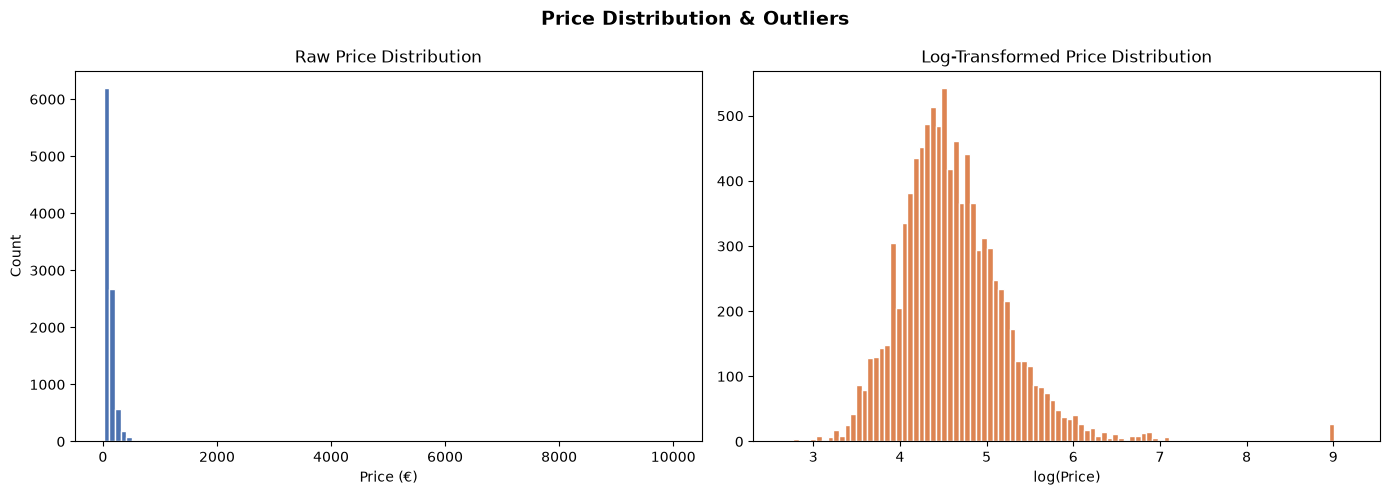

IQR bounds: €-46 - €254
Outliers: 673 rows (6.8%)
Max price: €10000  |  99th percentile: €829


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Price Distribution & Outliers", fontsize=14, fontweight="bold")

# Raw distribution
axes[0].hist(data["price"], bins=100, color="#4C72B0", edgecolor="white")
axes[0].set_title("Raw Price Distribution")
axes[0].set_xlabel("Price (€)")
axes[0].set_ylabel("Count")

# Log distribution
axes[1].hist(np.log1p(data["price"]), bins=100, color="#DD8452", edgecolor="white")
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("log(Price)")

plt.tight_layout()
plt.show()

# Print outlier stats
Q1 = data["price"].quantile(0.25)
Q3 = data["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data["price"] < lower) | (data["price"] > upper)]
print(f"IQR bounds: €{lower:.0f} - €{upper:.0f}")
print(f"Outliers: {len(outliers)} rows ({len(outliers) / len(data) * 100:.1f}%)")
print(
    f"Max price: €{data['price'].max():.0f}  |  99th percentile: €{data['price'].quantile(0.99):.0f}"
)

In [16]:
# Remove price outliers using IQR method
Q1 = data["price"].quantile(0.25)
Q3 = data["price"].quantile(0.75)
IQR = Q3 - Q1

data_clean = data[(data["price"] >= Q1 - 1.5 * IQR) & (data["price"] <= Q3 + 1.5 * IQR)]

print(f"Removed {len(data) - len(data_clean)} rows → {len(data_clean)} remaining")

Removed 673 rows → 9184 remaining


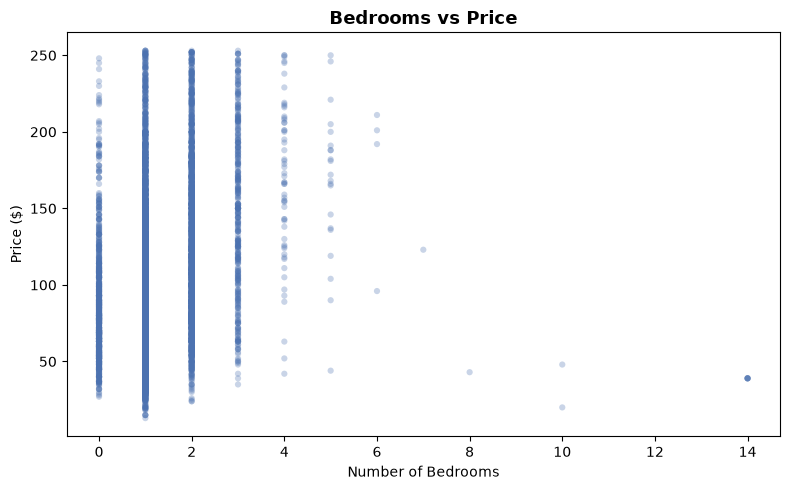

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    data_clean["bedrooms"], data_clean["price"], alpha=0.3, color="#4C72B0", edgecolors="none", s=20
)

ax.set_title("Bedrooms vs Price", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Bedrooms")
ax.set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

This chart shows which features have the strongest linear relationship with price. The most important takeaway is the ranking, it tells you which features the model will likely lean on most. Features like bedrooms, and bathrooms typically come out on top, meaning larger apartments simply cost more, which makes intuitive sense. Neighborhood and room type columns will also show up with meaningful correlations, confirming that where you are and what type of space it is matters a lot to price. Features near zero correlation (some amenities, for example) are candidates for dropping entirely, since they carry almost no price signal and just add noise to the model.

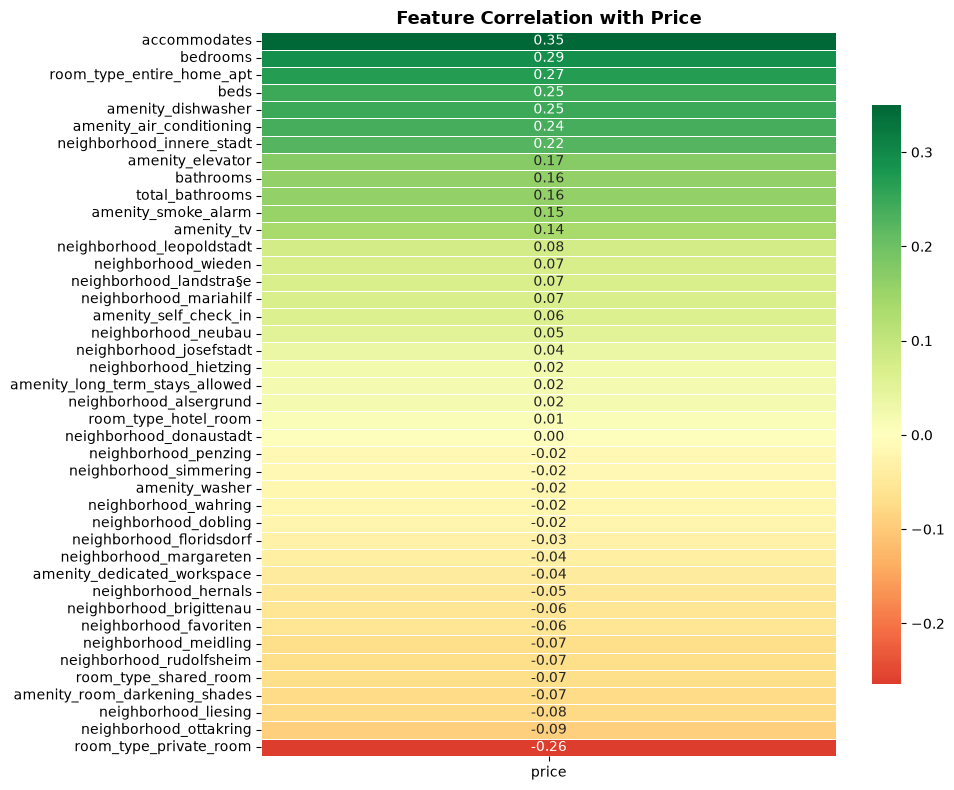

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

corr = (
    data_clean.corr(numeric_only=True)[["price"]]
    .drop("price")
    .sort_values("price", ascending=False)
)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8},
)

ax.set_title("Feature Correlation with Price", fontsize=13, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

This chart answers a more practical question than the heatmap: **does having this amenity actually translate to a higher nightly price?** It compares the median price of listings that have each amenity against those that don't, and shows the difference in dollars. This is important because an amenity could be very common (high frequency) yet have zero price impact, meaning guests don't pay more for it. Conversely, a less common amenity like `air conditioning` or `elevator` might command a significant premium, confirming it was worth including in the model. Any amenity showing near-zero or negative impact is worth reconsidering, it's likely not helping the model predict price and could be dropped to keep the feature space clean.

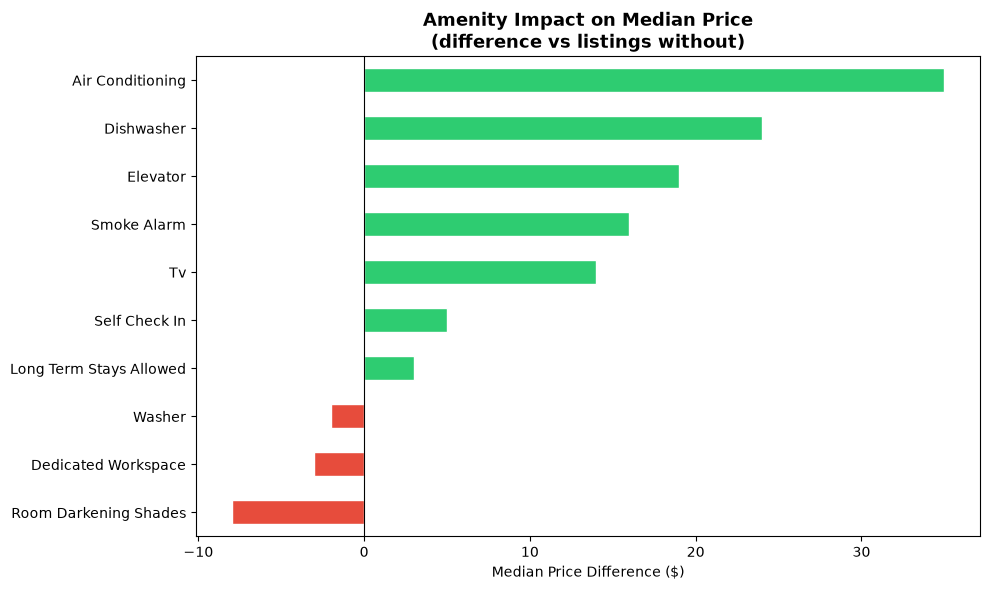

In [19]:
amenity_cols = [c for c in data_clean.columns if c.startswith("amenity_")]

amenity_impact = {}
for col in amenity_cols:
    has = data_clean[data_clean[col] == 1]["price"].median()
    has_not = data_clean[data_clean[col] == 0]["price"].median()
    amenity_impact[col.replace("amenity_", "").replace("_", " ").title()] = has - has_not

impact_df = pd.Series(amenity_impact).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in impact_df.values]
impact_df.plot(kind="barh", ax=ax, color=colors, edgecolor="white")

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(
    "Amenity Impact on Median Price\n(difference vs listings without)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Median Price Difference ($)")
plt.tight_layout()
plt.show()

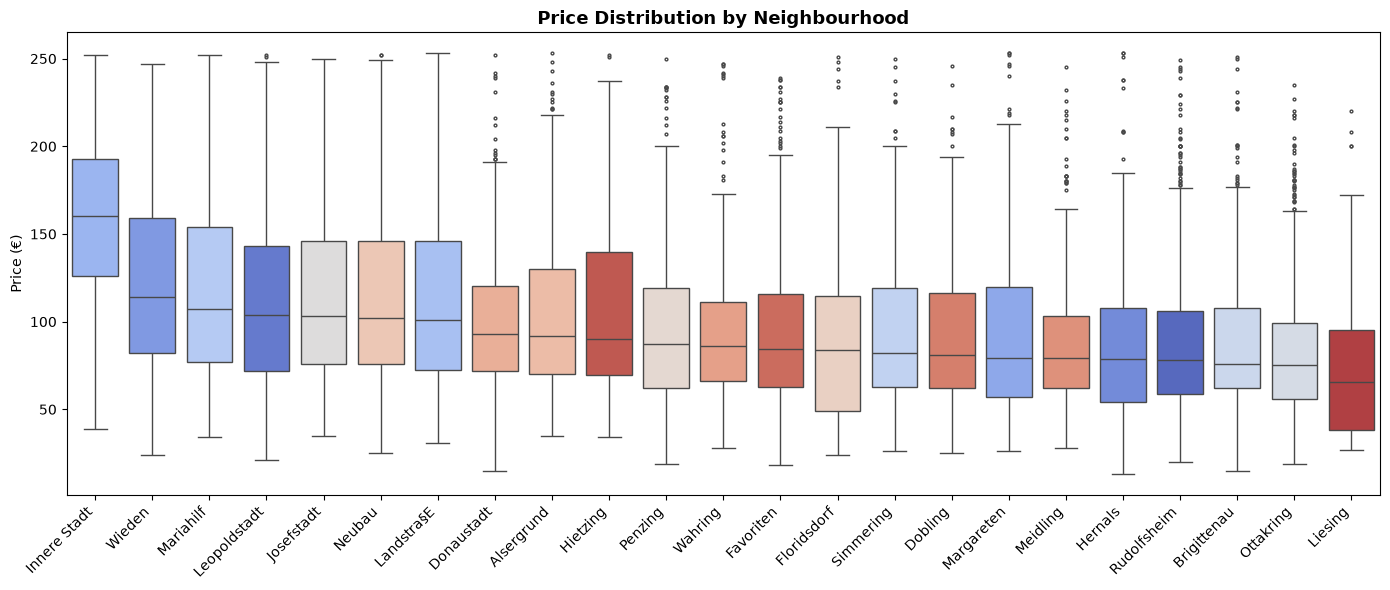

In [20]:
neighborhood_cols = [c for c in data_clean.columns if c.startswith("neighborhood_")]

# Reconstruct neighborhood label
data_clean["neighborhood"] = (
    data_clean[neighborhood_cols]
    .idxmax(axis=1)
    .str.replace("neighborhood_", "")
    .str.replace("_", " ")
    .str.title()
)

order = data_clean.groupby("neighborhood")["price"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=data_clean,
    x="neighborhood",
    y="price",
    order=order,
    hue="neighborhood",
    palette="coolwarm",
    fliersize=2,
    legend=False,
    ax=ax,
)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_title("Price Distribution by Neighbourhood", fontsize=13, fontweight="bold")
ax.set_ylabel("Price (€)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# drop the temporary 'neighborhood' column
data_clean = data_clean.drop(columns=["neighborhood"])

In [21]:
data_clean.info()

<class 'pandas.DataFrame'>
Index: 9184 entries, 0 to 14122
Data columns (total 43 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   accommodates                     9184 non-null   int64  
 1   bathrooms                        9184 non-null   float64
 2   total_bathrooms                  9184 non-null   float64
 3   bedrooms                         9184 non-null   float64
 4   beds                             9184 non-null   float64
 5   price                            9184 non-null   float64
 6   amenity_air_conditioning         9184 non-null   int64  
 7   amenity_elevator                 9184 non-null   int64  
 8   amenity_washer                   9184 non-null   int64  
 9   amenity_dishwasher               9184 non-null   int64  
 10  amenity_dedicated_workspace      9184 non-null   int64  
 11  amenity_self_check_in            9184 non-null   int64  
 12  amenity_tv                       91

In [22]:
#  Shuffle the data before saving

data_shuffled = data_clean.sample(frac=1, random_state=42).reset_index(drop=True)

data_shuffled.to_csv(
    "../04_part_Training_Evaluation_and_Model_Usage/data/airbnb_clean.csv",
    index=False,
)

print(f"Saved {len(data_shuffled)} rows to airbnb_clean.csv")

Saved 9184 rows to airbnb_clean.csv


In [ ]:
from pathlib import Path
import sys

# Supports starting Jupyter from this directory or the repository root.
ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "demo_support").is_dir() and (p / "requirements.txt").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the course repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from demo_support import visuals as v

v.setup_style()

from demo_support import airbnb

state = airbnb.load(ROOT)
state = airbnb.prepare(state)

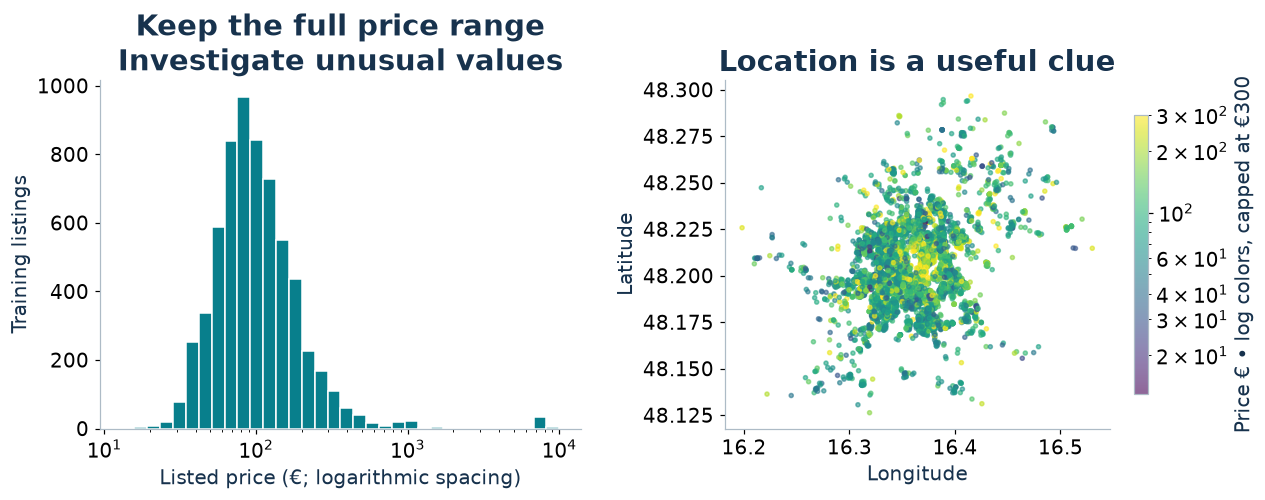

Training price summary,EUR
Median,93.0
95th percentile,300.0
Maximum,10000.0


In [24]:
airbnb.explore(state)

Clue,Examples,Role
Space,"Guests, bedrooms, beds, bathrooms",Input
Location,District and coordinates,Input
Type of accommodation,Entire place or a room,Input
Selected amenities,"Air conditioning, washer, TV",Input
Listing / host ID,Retained only for integrity and splitting,Not a model input
Listed price,The answer to predict,Target


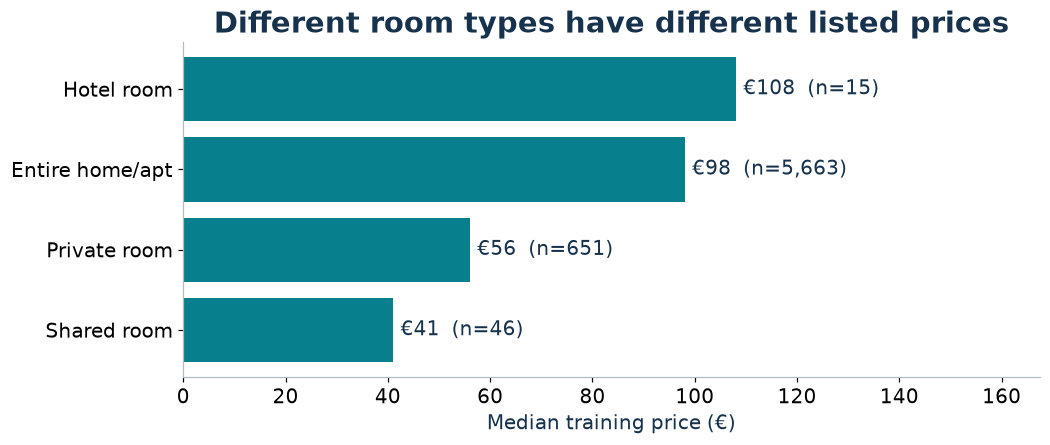

Amenity,Median difference (€),With amenity,Without amenity
Air conditioning,38.0,893,5482
Washer,0.0,2987,3388
TV,18.0,3519,2856


In [25]:
airbnb.features(state)